## Linear Models

### ARMAX
You may have noticed the similarity between the acronym NARMAX with the well-known models ARX, ARMAX, etc., which are widely used for forecasting time series. And this resemblance is not by chance. The AutoRegressive models with Moving Average and Exogenous Input (ARMAX) and their variations AR, ARX, ARMA (to name just a few) are one of the most used mathematical representations for identifying linear systems. The ARMAX can be expressed as:

$$
y_k = \phi \left[ y_{k-1}, \ldots, y_{k - n_y}, \mathbf{x}_{k-d}, \mathbf{x}_{k-d-1}, \ldots, \mathbf{x}_{k - d - n_z}, e_{k-1}, \ldots, e_{k - n_e} \right] + e_k \tag{2.5}
$$

Where:

- $n_y \in \mathbb{N}$, $n_x \in \mathbb{N}$, $n_e \in \mathbb{N}$ are the maximum lags for the system output, input, and noise regressors (representing the moving average part), respectively.
- $\mathbf{x}_k \in \mathbb{R}^{n_x}$ is the system input at discrete time $k \in \mathbb{N}$.
- $y_k \in \mathbb{R}^{n_y}$ is the system output at discrete time $k$.
- $e_k \in \mathbb{R}^{n_e}$ stands for uncertainties and possible noise at discrete time $k$.
- $\phi$ is some linear function of the input and output regressors.
- $d$ is a time delay, typically set to $d = 1$.

If $\phi$ is a polynomial, we have a **polynomial ARMAX model**:

$$
y_k = \sum_0 + \sum_{i=1}^{p} \Theta_{y_i} y_{k-i} + \sum_{j=1}^{q} \Theta_{e_j} e_{k-j} + \sum_{m=1}^{r} \Theta_{x_m} x_{k-m} + e_k \tag{2.6}
$$

Where:

- $\sum_0$ is a constant term,
- $\Theta_{y_i}$, $\Theta_{e_j}$, and $\Theta_{x_m}$ are constant parameters.

A particular example of a polynomial ARMAX model is:

$$
y_k = 0.7213\, y_{k-1} - 0.5692\, y_{k-2} + 0.1139\, x_{k-1} - 0.1691\, x_{k-1} + 0.2245\, e_{k-1} \tag{2.7}
$$



In [1]:
from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.parameter_estimation import LeastSquares

basis_function = Polynomial(degree=1)
model = FROLS(
    basis_function=basis_function,
    estimator=LeastSquares(unbiased=True)
)

In the example above, we define the linear polynomial basis function by importing the Polynomial basis and setting the degree equal to 1 (this ensures that we do not have a nonlinear combination of the regressors). Don't worry about the FROLS and LeastSquares yet. We'll talk about them in chapters 3 and 4, respectively.

For Figure 4, we conducted 10 separate simulations to analyse the effects of different noise process generation on the ARMAX system's behavior. Each simulation uses a unique sample of noise to observe how variations in this random component influence the overall system output. To illustrate this, we highlight one specific simulation while the others are displayed with less emphasis.

It's important to notice that all simulations, whether highlighted or not, are governed by the same underlying model. The deterministic part of the model equation explains the behavior of all the signals shown. The noticeable differences among the signals arise solely from the distinct noise samples used in each simulation. Despite these variations, the core dynamics of the signal remain consistent and are described by the model's deterministic component.

System equation example: y[k] = 0.9*y[k-1] - 0.24*y[k-2] + 0.92*u[k-1] + 0.92*nu[k-1] + nu[k]
Where y = [0.5, -0.1], u = [1], nu = [0.5, 0.3]
yk = 2.154


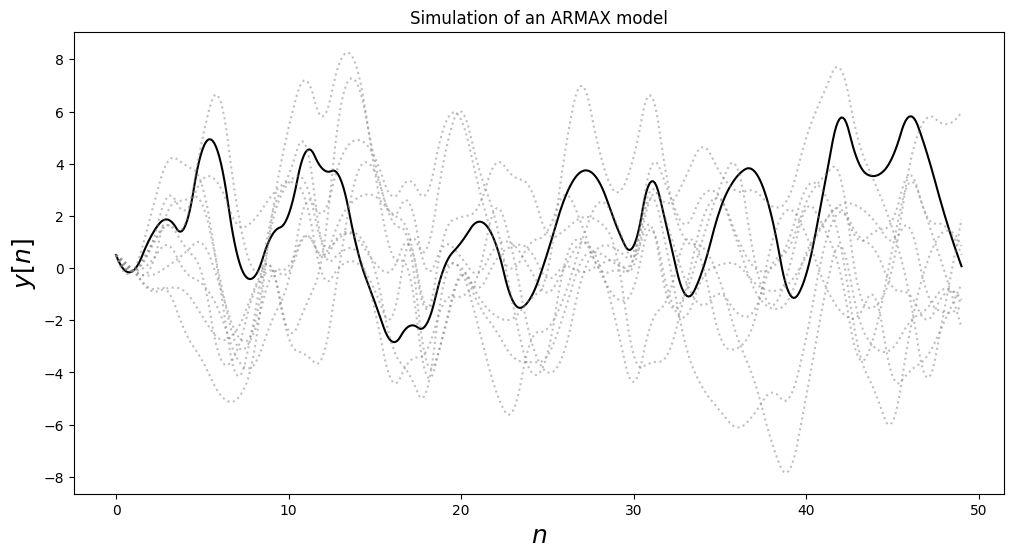

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

random_samples = 50
n = np.arange(random_samples)
def system_equation(y, u, nu):
    yk = 0.9*y[0] - 0.24*y[1] + 0.92*u[0] + 0.92*nu[0] + nu[1]
    return yk

print(f"System equation example: y[k] = 0.9*y[k-1] - 0.24*y[k-2] + 0.92*u[k-1] + 0.92*nu[k-1] + nu[k]")
print(f"Where y = [0.5, -0.1], u = [1], nu = [0.5, 0.3]")
print(f"yk = {system_equation([0.5, -0.1], [1], [0.5, 0.3])}")

u = np.random.normal(size=(random_samples,), scale=1)
nu = np.random.normal(size=(random_samples,), scale=0.9)
y = np.empty_like(nu)
# Initial Conditions
y0 = [0.5, -0.1]
y[0:2] = y0

X = []  # lista de entradas (lags)
Y = []  # lista de saídas correspondentes

for i in range(2, len(y)):
    regressor = [y[i-1], y[i-2], u[i-1], nu[i-1], nu[i]]
    X.append(regressor)
    Y.append(y[i])

X = np.array(X)
Y = np.array(Y).reshape(-1, 1)


# Create a single figure and axis for all plots
fig, ax = plt.subplots(figsize=(12, 6))
u = np.random.normal(size=(random_samples,), scale=1)
for k in range(10):
    nu = np.random.normal(size=(random_samples,), scale=0.9)
    y = np.empty_like(nu)
    # Initial Conditions
    y0 = [0.5, -0.1]
    y[0:2] = y0
    for i in range(2, len(y)):
        y[i] = system_equation([y[i - 1], y[i - 2]], [u[i - 1]], [nu[i - 1], nu[i]])

    # Interpolate the data just to make the plot "nicer"
    interpolation_function = interp1d(n, y, kind='quadratic')
    n_fine = np.linspace(n.min(), n.max(), 10*len(n)) # More points for a smoother curve
    y_interpolated = interpolation_function(n_fine)
    # Plotting the interpolated data
    if k == 0:
        ax.plot(n_fine, y_interpolated, color='k', alpha=1, linewidth=1.5)
    else:
        ax.plot(n_fine, y_interpolated, color='grey', linestyle=":", alpha=0.5, linewidth=1.5)

ax.set_xlabel("$n$", fontsize=18)
ax.set_ylabel("$y[n]$", fontsize=18)
ax.set_title("Simulation of an ARMAX model")
plt.show()

Exemplo, utilizando o sinal de rolamento com função de base Polinomial de grau 1 para definir o modelo.


🔍 Modelo identificado:


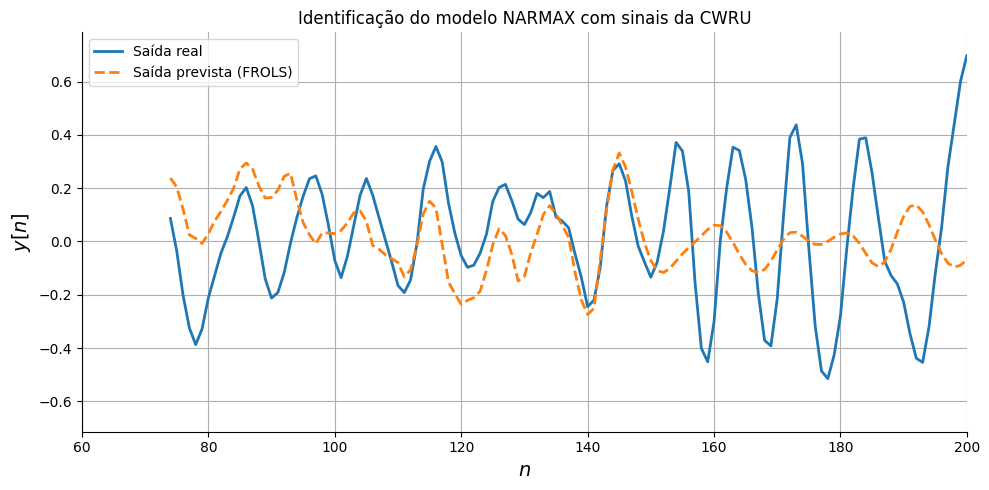

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.parameter_estimation import LeastSquares
from sysidentpy.utils.display_results import results

# Supondo que a classe CWRU esteja definida corretamente
from datasets import CWRU

# Carrega os sinais dos arquivos 174 e 175
dataset = CWRU()
metainfo = dataset.load_data_f({"filename": ["174", "175"]})
signal1, info1 = next(metainfo)
signal2, info2 = next(metainfo)

# Número de amostras
N = 1000
n = np.arange(N)  # ← define n corretamente para plotagem

# Define entrada e saída
X_input = signal1[0:N].reshape(-1, 1)
Y_output = signal2[0:N].reshape(-1, 1)

# Lags
xlag = 74
ylag = 74

# Função de base polinomial grau 2
basis_function = Polynomial(degree=2)

# Define o modelo
model = FROLS(
    basis_function=basis_function,
    estimator=LeastSquares(unbiased=False),
    model_type="NARMAX",
    ylag=ylag,
    xlag=xlag,
    elag=0,
    n_terms=3
)

# Treina o modelo
model.fit(X=X_input, y=Y_output)

# Previsão (usando mesmo Y_output para fins de avaliação)
y_hat = model.predict(X=X_input, y=Y_output)

# Exibe os termos selecionados
print("\n🔍 Modelo identificado:")
# print(results(model.final_model, model.theta))

# Cria figura
fig, ax = plt.subplots(figsize=(10, 5))

# Desloca n para alinhar com y_hat (por causa do lag)
n_id = n[max(xlag, ylag):]  # evita erro de índice

# Plota saída prevista e saída real
ax.plot(n_id, Y_output[max(xlag, ylag):].flatten(), label='Saída real', linewidth=2)
ax.plot(n_id, y_hat[:len(n_id)].flatten(), '--', label='Saída prevista (FROLS)', linewidth=2)

ax.set_xlabel("$n$", fontsize=14)
ax.set_ylabel("$y[n]$", fontsize=14)
ax.set_title("Identificação do modelo NARMAX com sinais da CWRU")
ax.legend()
ax.set_xlim([60, 200])
plt.grid(True)
plt.tight_layout()
plt.show()



🔍 Modelo identificado:


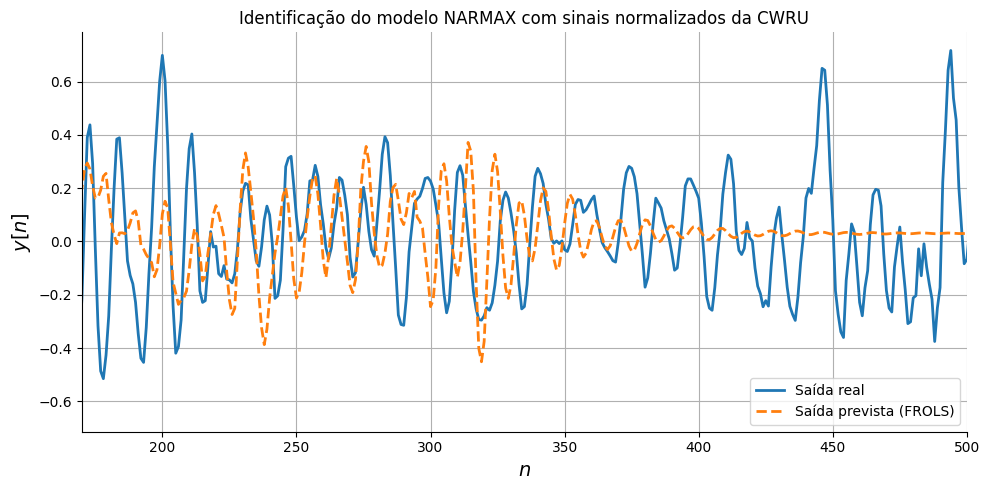

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial, Fourier
from sysidentpy.parameter_estimation import LeastSquares
from sysidentpy.utils.display_results import results

# Supondo que a classe CWRU esteja definida corretamente
from datasets import CWRU

# Carrega os sinais dos arquivos 174 e 175
dataset = CWRU()
metainfo = dataset.load_data_f({"filename": ["174", "175"]})
signal1, info1 = next(metainfo)
signal2, info2 = next(metainfo)

# Número de amostras
N = 1000
n = np.arange(N)

# Define entrada e saída originais
X_input_raw = signal1[0:N].reshape(-1, 1)
Y_output_raw = signal2[0:N].reshape(-1, 1)

# Normalização Z-score
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_input = x_scaler.fit_transform(X_input_raw)
Y_output = y_scaler.fit_transform(Y_output_raw)

# Lags
xlag = 160
ylag = 160

# Função de base polinomial grau 2
basis_function = Polynomial(degree=2)

# Define o modelo
model = FROLS(
    basis_function=basis_function,
    estimator=LeastSquares(unbiased=False),
    model_type="NARMAX",
    ylag=ylag,
    xlag=xlag,
    elag=0,
    n_terms=5
)

# Treina o modelo
model.fit(X=X_input, y=Y_output)

# Previsão (ainda normalizada)
y_hat_norm = model.predict(X=X_input, y=Y_output)

# Reverte a normalização para comparação
y_hat = y_scaler.inverse_transform(y_hat_norm)

# Exibe os termos selecionados
print("\n🔍 Modelo identificado:")
# print(results(model.final_model, model.theta))

# Cria figura
fig, ax = plt.subplots(figsize=(10, 5))

n_id = n[max(xlag, ylag):]

# Plota a saída real e prevista (em escala original)
ax.plot(n_id, Y_output_raw[max(xlag, ylag):].flatten(), label='Saída real', linewidth=2)
ax.plot(n_id, y_hat[:len(n_id)].flatten(), '--', label='Saída prevista (FROLS)', linewidth=2)

ax.set_xlabel("$n$", fontsize=14)
ax.set_ylabel("$y[n]$", fontsize=14)
ax.set_title("Identificação do modelo NARMAX com sinais normalizados da CWRU")
ax.legend()
ax.set_xlim([170, 500])
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


X = []  # lista de entradas (lags)
Y = []  # lista de saídas correspondentes

for i in range(2, len(y)):
    regressor = [y[i-1], y[i-2], u[i-1], nu[i-1], nu[i]]
    X.append(regressor)
    Y.append(y[i])

X = np.array(X)
Y = np.array(Y).reshape(-1, 1)


# Create a single figure and axis for all plots
fig, ax = plt.subplots(figsize=(12, 6))
u = np.random.normal(size=(random_samples,), scale=1)
for k in range(10):
    nu = np.random.normal(size=(random_samples,), scale=0.9)
    y = np.empty_like(nu)
    # Initial Conditions
    y0 = [0.5, -0.1]
    y[0:2] = y0
    for i in range(2, len(y)):
        y[i] = system_equation([y[i - 1], y[i - 2]], [u[i - 1]], [nu[i - 1], nu[i]])

    # Interpolate the data just to make the plot "nicer"
    interpolation_function = interp1d(n, y, kind='quadratic')
    n_fine = np.linspace(n.min(), n.max(), 10*len(n)) # More points for a smoother curve
    y_interpolated = interpolation_function(n_fine)
    # Plotting the interpolated data
    if k == 0:
        ax.plot(n_fine, y_interpolated, color='k', alpha=1, linewidth=1.5)
    else:
        ax.plot(n_fine, y_interpolated, color='grey', linestyle=":", alpha=0.5, linewidth=1.5)

ax.set_xlabel("$n$", fontsize=18)
ax.set_ylabel("$y[n]$", fontsize=18)
ax.set_title("Simulation of an ARMAX model")
plt.show()

## NARMAX

You can easily build a polynomial NARMAX model using SysIdentPy. Note that the difference for ARMAX, in this case, is the degree of the polynomial function.

In [ ]:
from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.parameter_estimation import LeastSquares

basis_function = Polynomial(degree=2)
model = FROLS(
    basis_function=basis_function,
    estimator=LeastSquares(unbiased=True)
)
model

Let's use SysIdentPy to see how the search space grows in the linear versus the nonlinear scenario. The count_model_regressors method available in narmax_tools can be used the check how many regressors exists in the search space given the number of inputs, the delays of y and x regressors and the basis function. We will use xlag=ylag=10 and the polynomial basis function. The user can simulate different scenarios by setting different parameters.

In [ ]:
from sysidentpy.utils.information_matrix import count_model_regressors
from sysidentpy.basis_function import Polynomial
import numpy as np

In [ ]:
x_train = np.random.rand(4096, 1)  # simulating a case with 1 input
y_train = np.random.rand(4096, 1)
basis_function = Polynomial(degree=1)
n_regressors = count_model_regressors(
    x=x_train,
    y=y_train,
    xlag=10,
    ylag=10,
    model_type="NARMAX",
    basis_function=basis_function,
    is_neural_narx=False,
)
n_regressors

For the linear case with 2 inputs, the number of regressors jumps to 31:

In [ ]:
x_train = np.random.rand(4096, 2)  # simulating a case with 2 inputs
y_train = np.random.rand(4096, 1)
basis_function = Polynomial(degree=1)
xlag = [list(range(1, 11))] * x_train.shape[1]
print(xlag)
n_regressors = count_model_regressors(
    x=x_train,
    y=y_train,
    xlag=xlag,
    ylag=10,
    model_type="NARMAX",
    basis_function=basis_function,
    is_neural_narx=False,
)
n_regressors


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

random_samples = 50
n = np.arange(random_samples)
def system_equation(y, u, nu):
    yk = 0.9*y[0] - 0.24*y[1] + 0.92*u[0] + 0.92*nu[0] + nu[1]
    return yk

# Create a single figure and axis for all plots
fig, ax = plt.subplots(figsize=(12, 6))
u = np.random.normal(size=(random_samples,), scale=1)
for k in range(10):
    nu = np.random.normal(size=(random_samples,), scale=0.9)
    y = np.empty_like(nu)
    # Initial Conditions
    y0 = [0.5, -0.1]
    y[0:2] = y0
    for i in range(2, len(y)):
        y[i] = system_equation([y[i - 1], y[i - 2]], [u[i - 1]], [nu[i - 1], nu[i]])

    # Interpolate the data just to make the plot "nicer"
    interpolation_function = interp1d(n, y, kind='quadratic')
    n_fine = np.linspace(n.min(), n.max(), 10*len(n)) # More points for a smoother curve
    y_interpolated = interpolation_function(n_fine)
    # Plotting the interpolated data
    if k == 0:
        ax.plot(n_fine, y_interpolated, color='k', alpha=1, linewidth=1.5)
    else:
        ax.plot(n_fine, y_interpolated, color='grey', linestyle=":", alpha=0.5, linewidth=1.5)

ax.set_xlabel("$n$", fontsize=18)
ax.set_ylabel("$y[n]$", fontsize=18)
ax.set_title("Simulation of an ARMAX model")
plt.show()

x_train.shape = (800, 1), x_valid = (200, 1), y_train.shape = (800, 1)


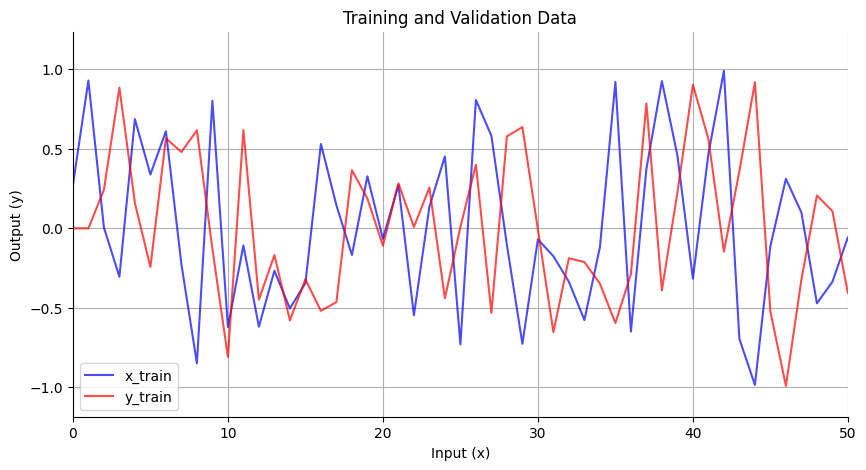

In [2]:
from torch import nn
import torch
import matplotlib.pyplot as plt

from sysidentpy.neural_network import NARXNN
from sysidentpy.basis_function import Polynomial
from sysidentpy.utils.generate_data import get_siso_data
from sysidentpy.utils.narmax_tools import regressor_code

# simulated data
x_train, x_valid, y_train, y_valid = get_siso_data(
    n=1000, colored_noise=False, sigma=0.01, train_percentage=80
)

print(f"x_train.shape = {x_train.shape}, x_valid = {x_valid.shape}, y_train.shape = {y_train.shape}")
n_train = [i for i in range(len(x_train))]
n_val = [i for i in range(len(x_valid))]
# Plot the training data
plt.figure(figsize=(10, 5))
plt.plot(n_train, x_train, label='x_train', color='blue', alpha=0.7)
plt.plot(n_train, y_train, label='y_train', color='red', alpha=0.7)
# plt.plot(n_val, x_valid, label='Validation Data', color='orange', alpha=0.7)
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.title('Training and Validation Data')
plt.xlim([0, 50])
plt.legend()
plt.grid()
plt.show()

In [3]:
torch.cuda.is_available()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [4]:
# Creating the NARXNN model

basis_function = Polynomial(degree=1)
narx_net = NARXNN(
    ylag=2,
    xlag=2,
    basis_function=basis_function,
    model_type="NARMAX",
    loss_func="mse_loss",
    optimizer="Adam",
    epochs=2000,
    verbose=False,
    device=device,
    optim_params={
        "betas": (0.9, 0.999),
        "eps": 1e-05,
    }, # optional parameters of the optimizer
)

If you need help finding how many regressors are created behind the scenes you can use the narmax_tools function regressor_code and take the size of the regressor code generated:

In [7]:
from sysidentpy.utils.information_matrix import count_model_regressors

basis_function = Polynomial(degree=1)
n_regressors = count_model_regressors(
    x=x_train,
    y=y_train,
    xlag=2,
    ylag=2,
    model_type="NARMAX",
    basis_function=basis_function,
    is_neural_narx=True,
)
n_regressors

4

The configuration of your network follows exactly the same pattern of a network defined in Pytorch. The following representing our NARX neural network.

In [8]:
class NARX(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(n_regressors, 30)
        self.lin2 = nn.Linear(30, 30)
        self.lin3 = nn.Linear(30, 1)
        self.tanh = nn.Tanh()


    def forward(self, xb):
        z = self.lin(xb)
        z = self.tanh(z)
        z = self.lin2(z)
        z = self.tanh(z)
        z = self.lin3(z)
        return z

The user have to pass the defined network to our NARXNN estimator and set cuda if available (or needed):

In [9]:
narx_net.net = NARX()

if device == "cuda":
    narx_net.net.to(torch.device("cuda"))

Because we have a fit (for training) and predict function for Polynomial NARMAX, we create the same pattern for the NARX net. So, you only have to fit and predict using the following:

In [10]:
narx_net.fit(X=x_train, y=y_train, X_test=x_valid, y_test=y_valid)
yhat = narx_net.predict(X=x_valid, y=y_valid)

If the net configuration is built before calling the NARXNN, just pass the model to the NARXNN as follows:

In [20]:
class NARX(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(120, 100)
        self.lin2 = nn.Linear(100, 30)
        self.lin3 = nn.Linear(30, 1)
        self.tanh = nn.Tanh()


    def forward(self, xb):
        z = self.lin(xb)
        z = self.tanh(z)
        z = self.lin2(z)
        z = self.tanh(z)
        z = self.lin3(z)
        return z


narx_net2 = NARXNN(
    net=NARX(),
    ylag=60,
    xlag=60,
    basis_function=basis_function,
    model_type="NARMAX",
    loss_func="mse_loss",
    optimizer="Adam",
    epochs=20,
    verbose=False,
    optim_params={
        "betas": (0.9, 0.999),
        "eps": 1e-05,
    }, # optional parameters of the optimizer
)

narx_net2.fit(X=x_train, y=y_train)
yhat = narx_net2.predict(X=x_valid, y=y_valid)

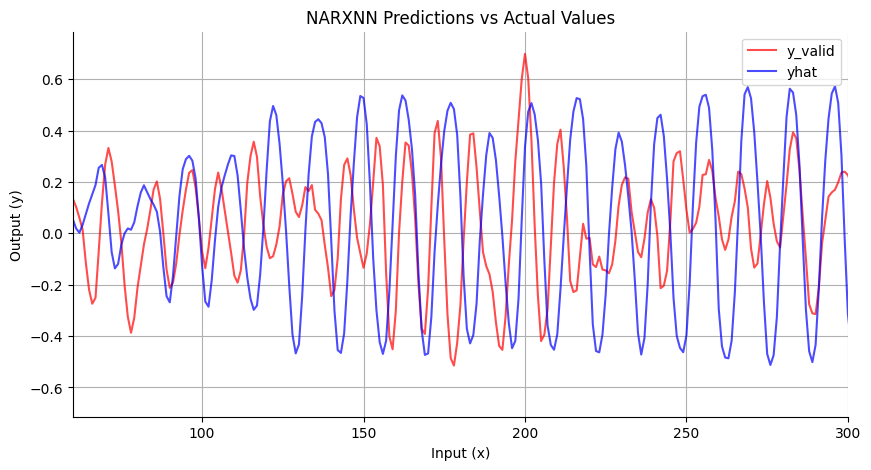

In [25]:
# Plot y vs yhat
n_train = [i for i in range(len(x_train))]
n_val = [i for i in range(len(x_valid))]
plt.figure(figsize=(10, 5))
plt.plot(n_val, y_valid, label='y_valid', color='red', alpha=0.7)
plt.plot(n_val, yhat, label='yhat', color='blue', alpha=0.7)
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.title('NARXNN Predictions vs Actual Values')
plt.xlim([60, 300])
plt.legend()
plt.grid()
plt.show()

In [116]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def normalize_signal(signal):   
    scaler = MinMaxScaler()
    norm_signal = scaler.fit_transform(signal)
    return norm_signal, scaler

def denormalize_signal(norm_signal, scaler):
    return scaler.inverse_transform(norm_signal)


In [117]:
# Parameters

d = 128
sample_size = 4096
lag = 300
root_dir = "data/raw/cwru"
x_file = "109"
y_file = "174"

In [118]:
from torch import nn
import torch
import matplotlib.pyplot as plt

from sysidentpy.neural_network import NARXNN
from sysidentpy.basis_function import Polynomial, Fourier
from sysidentpy.utils.information_matrix import count_model_regressors

from sklearn.preprocessing import MinMaxScaler

from datasets import CWRU

print(f"y_file = {y_file}")

# Load dataset
dataset = CWRU()

# x_subsets = [dataset.load_file(f"{root_dir}/{file}.mat")[0] for file in x_files]
x_set = dataset.load_file(f"{root_dir}/{x_file}.mat")[0]
y_set = dataset.load_file(f"{root_dir}/{y_file}.mat")[0]

# max_size_enable = min([x.shape[0] for x in x_set]+[y_set.shape[0]])
max_size_enable = min([x_set.shape[0]]+[y_set.shape[0]])
print(f"Max size of subsets: {max_size_enable}")

# x_train = np.array([sig[:sample_size].reshape(-1, 1) for sig in x_set]).squeeze().T
# x_valid = np.array([sig[d:(d+sample_size)].reshape(-1, 1) for sig in x_set]).squeeze().T

x_train = x_set[:sample_size].reshape(-1, 1)
x_valid = x_set[d:(sample_size+d)].reshape(-1, 1)

y_train = y_set[:sample_size].reshape(-1, 1)
y_valid = y_set[d:(sample_size+d)].reshape(-1, 1)

# x_train_scaled, scaler_xt = normalize_signal(x_train)
# x_valid_scaled, scaler_xv = normalize_signal(x_valid)
# y_train_scaled, scaler_yt = normalize_signal(y_train)
# y_valid_scaled, scaler_yv = normalize_signal(y_valid)

print(f"x_train.shape = {x_train.shape}, x_valid = {x_valid.shape}, y_train.shape = {y_train.shape}")

basis_function = Polynomial(degree=1)
n_regressors = count_model_regressors(
    x=x_train,
    y=y_train,
    xlag = lag,
    ylag = lag,
    model_type="NARMAX",
    basis_function=basis_function,
    is_neural_narx=True,
)
print(f"n_regressors -> {n_regressors}")

print(x_train.shape)
class NARX(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(n_regressors, 64)
        self.lin2 = nn.Linear(64, 32)
        self.lin3 = nn.Linear(32, 1)
        self.tanh = nn.Tanh()

    def forward(self, xb):
        z = self.lin(xb)
        z = self.tanh(z)
        z = self.lin2(z)
        z = self.tanh(z)
        z = self.lin3(z)
        return z


narx_net = NARXNN(
    net=NARX(),
    xlag = lag,
    ylag = lag,
    basis_function=basis_function,
    model_type="NARMAX",
    loss_func="mse_loss",
    optimizer="Adam",
    epochs=2000,
    verbose=False,
    optim_params={
        "betas": (0.9, 0.999),
        "eps": 1e-05,
    }, # optional parameters of the optimizer
)

narx_net.fit(X=x_train, y=y_train)
torch.save(narx_net.net.state_dict(), f"saved_models/narx_net_{y_file}.pth")
# yhat = narx_net.predict(X=x_valid, y=y_valid)

y_file = 174
Max size of subsets: 63788
x_train.shape = (4096, 1), x_valid = (4096, 1), y_train.shape = (4096, 1)
n_regressors -> 600
(4096, 1)


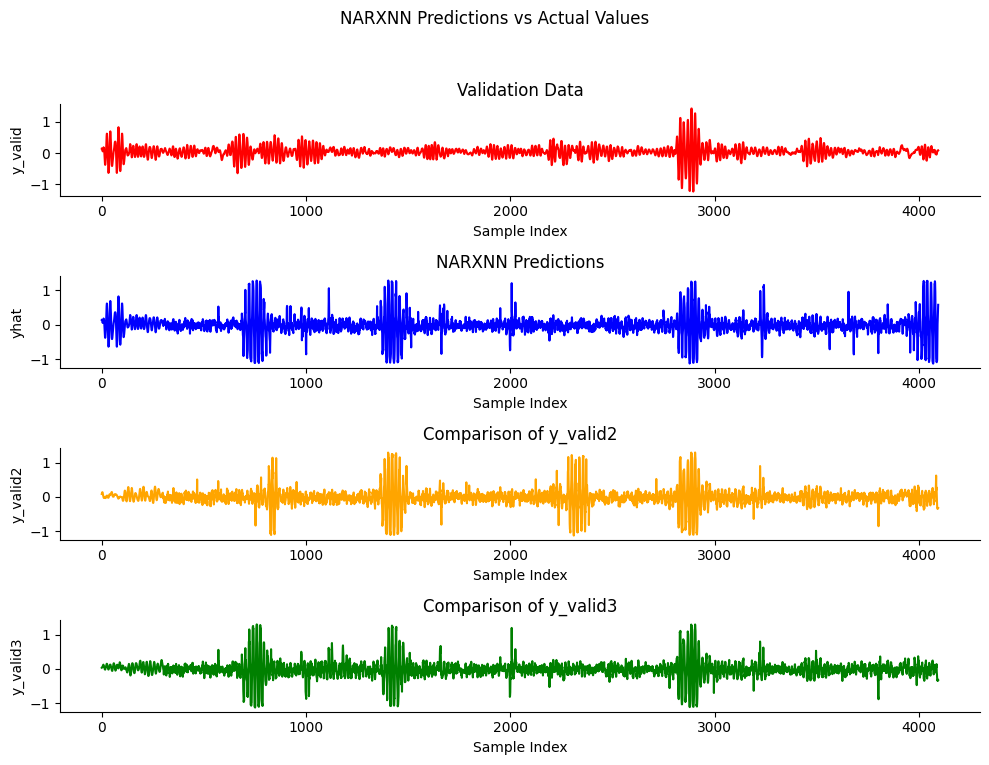

In [119]:
root_dir = "data/processed/cwru_aug/021/I"
# for i in range(max_size_enable// sample_size):
#     yval = y_set[i*sample_size:(i+1)*sample_size].reshape(-1, 1)
#     yhat = narx_net.predict(X=x_valid, y=yval)
#     np.save(f"{root_dir}/sample_{y_file}_{i}.npy", yhat)
yhat = narx_net.predict(X=x_valid, y=y_valid)

y_valid2 = y_set[2*sample_size:3*sample_size].reshape(-1, 1)
yhat2 = narx_net.predict(X=x_valid, y=y_valid2)

y_valid3 = y_set[3*sample_size:4*sample_size].reshape(-1, 1)
yhat3 = narx_net.predict(X=x_valid, y=y_valid3)

plt.figure(figsize=(10, 8))
plt.suptitle('NARXNN Predictions vs Actual Values')

plt.subplot(411)
plt.plot(y_valid, label='y_valid', color='red')
plt.ylabel('y_valid')
plt.xlabel('Sample Index')
plt.title('Validation Data')

plt.subplot(412)
plt.plot(yhat, label='yhat', color='blue')
plt.ylabel('yhat')
plt.xlabel('Sample Index')
plt.title('NARXNN Predictions')

plt.subplot(413)
plt.plot(yhat2, label='yhat2', color='orange')
plt.ylabel('y_valid2')
plt.xlabel('Sample Index')
plt.title('Comparison of y_valid2')

plt.subplot(414)
plt.plot(yhat3, label='yhat3', color='green')
plt.ylabel('y_valid3')
plt.xlabel('Sample Index')
plt.title('Comparison of y_valid3')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fft(signal, fs=48000, title="FFT of the Signal"):
    n = len(signal)
    freq = np.fft.rfftfreq(n, d=1/fs)  # Frequências positivas
    fft_vals = np.fft.rfft(signal)     # FFT unilateral
    magnitude = np.abs(fft_vals)       # Módulo da FFT

    plt.figure(figsize=(10, 4))
    plt.plot(freq, magnitude, color='blue')
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


yhat.shape = (4096, 1)


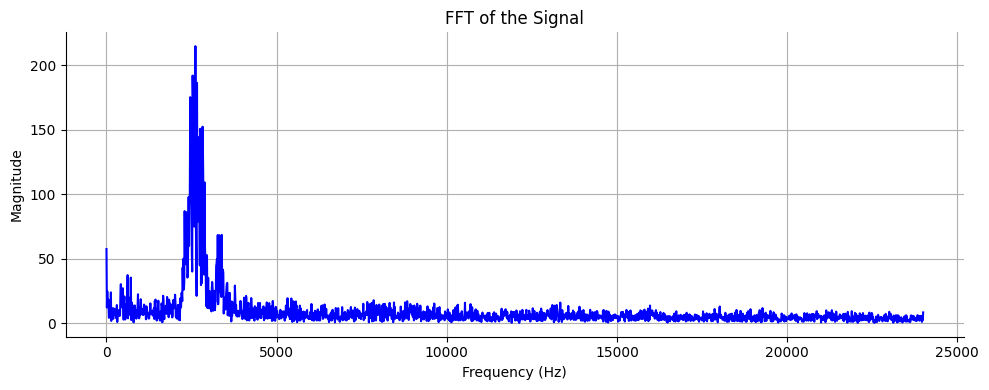

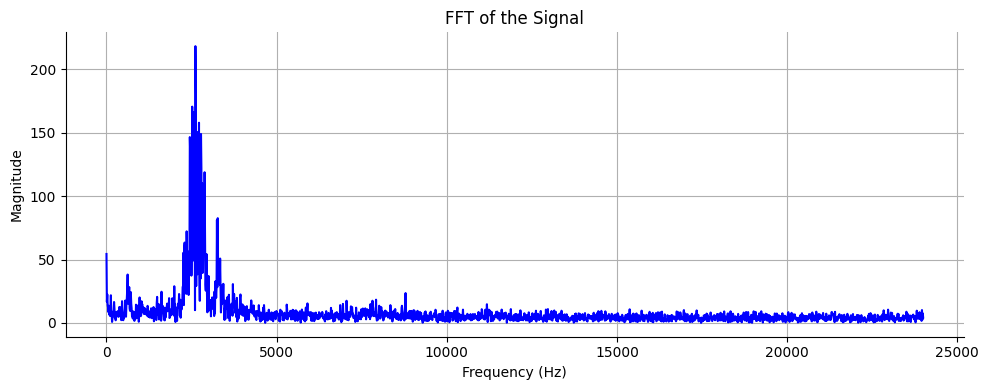

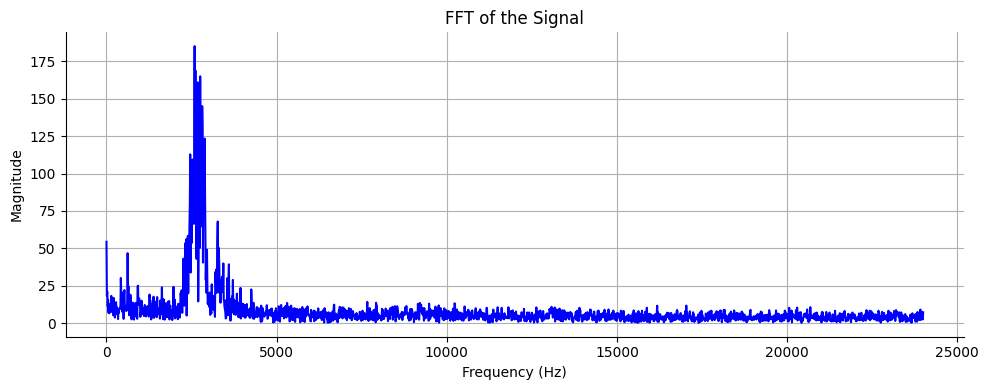

In [127]:
print(f"yhat.shape = {yhat.shape}")
plot_fft(yhat.flatten())
plot_fft(yhat2.flatten())
plot_fft(yhat3.flatten())

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.neural_network import NARXNN
from torch import nn
from sklearn.preprocessing import MinMaxScaler

# Simulate input signals (e.g., 3 input vibration signals)
np.random.seed(42)
n_samples = 1000
x1 = np.sin(np.linspace(0, 10 * np.pi, n_samples)) + np.random.normal(0, 0.1, n_samples)
x2 = np.cos(np.linspace(0, 10 * np.pi, n_samples)) + np.random.normal(0, 0.1, n_samples)
x3 = np.sin(np.linspace(0, 5 * np.pi, n_samples)) + np.random.normal(0, 0.1, n_samples)

# Target is a nonlinear function of the inputs
y = (0.4 * x1 + 0.3 * x2 ** 2 - 0.2 * x3 + 0.1 * np.random.normal(0, 1, n_samples))

# Reshape for sysidentpy (n_samples, 1)
x_train = np.column_stack((x1, x2, x3))
y_train = y.reshape(-1, 1)

# Normalize signals
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
x_train = scaler_x.fit_transform(x_train)
y_train = scaler_y.fit_transform(y_train)

# Train/test split
split = int(0.8 * n_samples)
x_test = x_train[split:]
y_test = y_train[split:]
x_train = x_train[:split]
y_train = y_train[:split]

from sysidentpy.utils.utils import build_lagged_matrix

# Gera os dados lagged corretamente com base em xlag e ylag
X_lagged, y_lagged = build_lagged_matrix(
    x=x_train,
    y=y_train,
    xlag=xlag,
    ylag=ylag,
    model_type="NARX"
)

# Agora sabemos o shape correto da entrada
input_size = X_lagged.shape[1]

# Rede compatível com o tamanho real da entrada
net = nn.Sequential(
    nn.Linear(input_size, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)


model = NARXNN(
    net=net,
    ylag=ylag,
    xlag=xlag,
    epochs=200,
    learning_rate=0.01,
    optim_params={},
    verbose=False
)

model.fit(X=x_train, y=y_train, X_test=x_test, y_test=y_test)

# Prediction
y_pred = model.predict(X=x_test, y=y_test)

# Inverse transform for interpretation
y_test_real = scaler_y.inverse_transform(y_test)
y_pred_real = scaler_y.inverse_transform(y_pred)

# Calculate Pearson correlation
corr, _ = pearsonr(y_test_real.flatten(), y_pred_real.flatten())

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(y_test_real, label='Real', alpha=0.7)
plt.plot(y_pred_real, label='Predicted', alpha=0.7)
plt.title(f"Prediction vs Real Output | Pearson r = {corr:.3f}")
plt.xlabel("Time Index")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'sysidentpy.utils.utils'

In [31]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

from datasets import CWRU

dataset = CWRU()

# Simulando sinais de vibração
def generate_signal(path, sample_size=4096):
    signal = dataset.load_file(path)[0]
    return signal[:sample_size]

def generate_segments(list_files, sample_size=4096):
    segments = []
    for file in list_files:
        signal = dataset.load_file(f"data/raw/cwru/{file}.mat")[0]
        num_segments = 5 #len(signal)//sample_size
        for i in range(num_segments):
            segments.append(signal[i*(sample_size):(i+1)*sample_size])        
    return np.stack(segments, axis=1)

# Lista dos nomes dos arquivos pela severidade
list_files_007 = [109, 110, 111, 112]
list_files_021 = [213, 214, 215, 217]

# Entradas: 4 sinais de severidade 007
severity_007 = generate_segments(list_files=list_files_007)

# Alvo de treino: severidade 021
severity_021 = generate_segments(list_files=list_files_021)

# Normalização
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_scaled = scaler_x.fit_transform(severity_007)
y_train_scaled = scaler_y.fit_transform(severity_021.reshape(-1, 1)).flatten()

# Criação de janelas temporais
def create_sequences(x, y, seq_len):
    X, Y = [], []
    for i in range(len(x) - seq_len):
        X.append(x[i:i+seq_len])
        Y.append(y[i+seq_len])
    return np.array(X), np.array(Y)

seq_len = 160
X_train, y_train = create_sequences(x_scaled, y_train_scaled, seq_len)

# Conversão para tensores
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)


# Modelo inspirado em NARX (Feedforward com sequência)
class NARXNet(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(NARXNet, self).__init__()
        self.fc1 = nn.Linear(input_size * seq_len, hidden_size)
        self.relu = nn.Tanh()
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten sequence
        x = self.relu(self.fc1(x))
        return self.fc2(x)

# Instanciando e treinando
input_size = X_train.shape[2]
print(input_size)
model = NARXNet(input_size=input_size, hidden_size=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


20
Epoch 0, Loss: 0.5000
Epoch 20, Loss: 0.0103
Epoch 40, Loss: 0.0093
Epoch 60, Loss: 0.0092
Epoch 80, Loss: 0.0086
Epoch 100, Loss: 0.0085
Epoch 120, Loss: 0.0085
Epoch 140, Loss: 0.0085
Epoch 160, Loss: 0.0084
Epoch 180, Loss: 0.0084


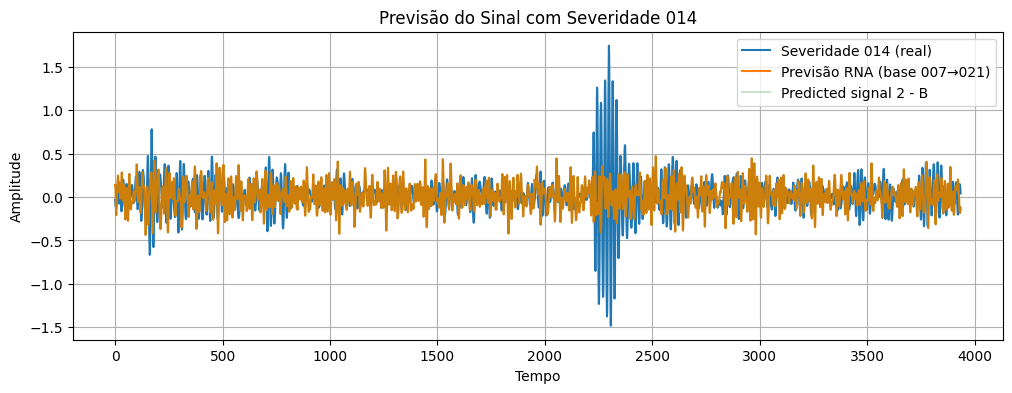

In [ ]:
# Alvo de teste: severidade 014
severity_014 = generate_signal("data/raw/cwru/176.mat", 4096)
y_test_scaled = scaler_y.transform(severity_014.reshape(-1, 1)).flatten()
X_test, y_test = create_sequences(x_scaled, y_test_scaled, seq_len)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Teste: prever severidade 014
model.eval()
with torch.no_grad():
    predictions = model(X_test).squeeze().numpy()

# Revertendo escala
predicted_signal = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
true_signal = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Visualização
plt.figure(figsize=(12, 4))
plt.plot(true_signal, label="Severidade 014 (real)")
plt.plot(predicted_signal, label="Previsão RNA (base 007→021)")
plt.legend()
plt.title("Previsão do Sinal com Severidade 014")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
import numpy as np

# true_signal: sinal real (severidade 014)
# predicted_signal: previsão da RNA

mae = mean_absolute_error(true_signal, predicted_signal)
mse = mean_squared_error(true_signal, predicted_signal)
rmse = np.sqrt(mse)
r, _ = pearsonr(true_signal, predicted_signal)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Correlação de Pearson (r): {r:.4f}")


MAE: 0.1751
MSE: 0.0671
RMSE: 0.2590
Correlação de Pearson (r): -0.0143


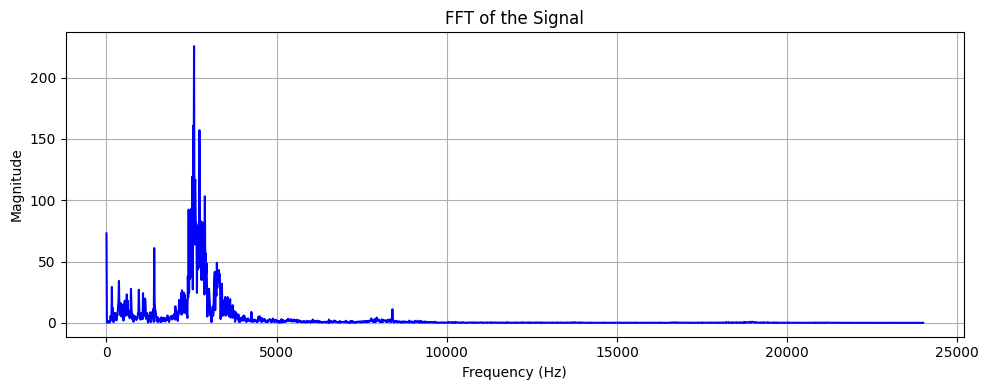

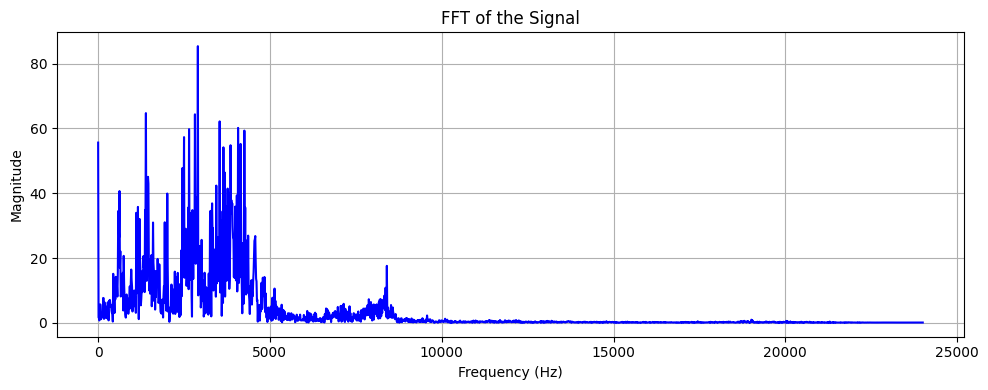

In [34]:
plot_fft(true_signal)
plot_fft(predicted_signal)

In [100]:
# Lista dos nomes dos arquivos pela severidade
list_files_007 = [122, 123, 124, 125]
list_files_021 = [226, 227, 228, 229]

# Entradas: 4 sinais de severidade 007
severity_007 = generate_segments(list_files=list_files_007)

# Alvo de treino: severidade 021
severity_021 = generate_segments(list_files=list_files_021)

# Normalização
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_scaled = scaler_x.fit_transform(severity_007)
y_train_scaled = scaler_y.fit_transform(severity_021.reshape(-1, 1)).flatten()

seq_len = 160
X_train, y_train = create_sequences(x_scaled, y_train_scaled, seq_len)

# Conversão para tensores
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Instanciando e treinando
input_size = X_train.shape[2]
model = NARXNet(input_size=input_size, hidden_size=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 0.3138
Epoch 20, Loss: 0.0270
Epoch 40, Loss: 0.0100
Epoch 60, Loss: 0.0087
Epoch 80, Loss: 0.0086
Epoch 100, Loss: 0.0084
Epoch 120, Loss: 0.0083
Epoch 140, Loss: 0.0082
Epoch 160, Loss: 0.0082
Epoch 180, Loss: 0.0081
Epoch 200, Loss: 0.0081
Epoch 220, Loss: 0.0080
Epoch 240, Loss: 0.0080
Epoch 260, Loss: 0.0079
Epoch 280, Loss: 0.0079


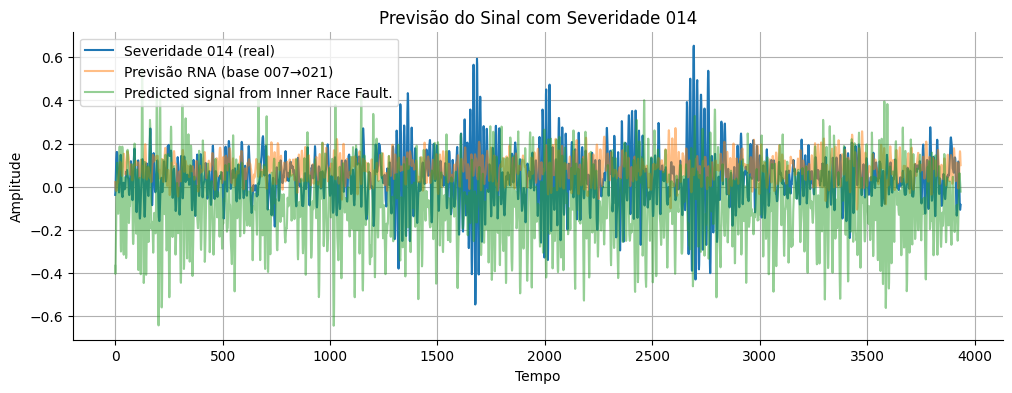

In [101]:
# Alvo de teste: severidade 014
severity_014 = generate_signal("data/raw/cwru/189.mat", 4096)
y_test_scaled_b = scaler_y.transform(severity_014.reshape(-1, 1)).flatten()
X_test_b, y_test = create_sequences(x_scaled, y_test_scaled_b, seq_len)
X_test_b = torch.tensor(X_test_b, dtype=torch.float32)

# Teste: prever severidade 014
model.eval()
with torch.no_grad():
    predictions = model(X_test_b).squeeze().numpy()

# Revertendo escala
predicted_signal_b = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
true_signal_b = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Visualização
plt.figure(figsize=(12, 4))
plt.plot(true_signal_b, label="Severidade 014 (real)")
plt.plot(predicted_signal_b, label="Previsão RNA (base 007→021)", alpha=0.5)
plt.plot(predicted_signal, label="Predicted signal from Inner Race Fault.", alpha=0.5)
plt.legend()
plt.title("Previsão do Sinal com Severidade 014")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

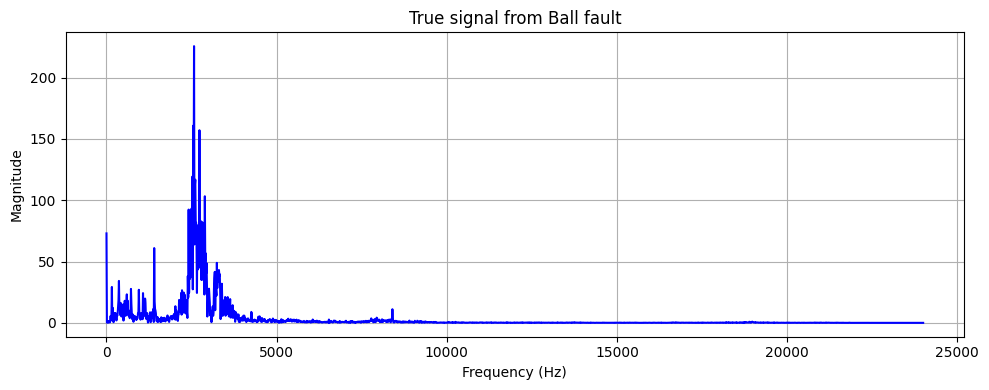

NameError: name 'predicted_signal_b' is not defined

In [18]:
plot_fft(true_signal, title="True signal from Ball fault")
plot_fft(predicted_signal_b, title="Predicted signal from B")
plot_fft(predicted_signal, title="Predicted signal from Inner Race fault.")

In [105]:
mse = mean_squared_error(true_signal_b, predicted_signal_b)
rmse = np.sqrt(mse)
rmse

0.14183107664498976

In [12]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import random

from datasets import CWRU


# Simulando sinais de vibração
def generate_signal(dataset, path, sample_size=4096):
    signal = dataset.load_file(path)[0]
    random_choise = random.randint(1, len(signal)//sample_size)-1
    return signal[random_choise*sample_size:(random_choise+1)*sample_size]

def generate_segments(dataset, list_files, sample_size=4096):
    segments = []
    for file in list_files:
        signal = dataset.load_file(f"data/raw/cwru/{file}.mat")[0]
        num_segments = len(signal)//sample_size
        random_choise = random.randint(1, num_segments)-1
        segments.append(signal[random_choise*(sample_size):(random_choise+1)*sample_size])        
    return np.stack(segments, axis=1)

# Criação de janelas temporais
def create_sequences(x, y, seq_len):
    X, Y = [], []
    for i in range(len(x) - seq_len):
        X.append(x[i:i+seq_len])
        Y.append(y[i+seq_len])
    return np.array(X), np.array(Y)

# Modelo inspirado em NARX (Feedforward com sequência)
class NARXNet(nn.Module):
    def __init__(self, input_size, hidden_size, seq_len):
        super(NARXNet, self).__init__()
        self.fc1 = nn.Linear(input_size * seq_len, hidden_size)
        self.relu = nn.Tanh()
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten sequence
        x = self.relu(self.fc1(x))
        return self.fc2(x)

def data_augmentation(output_path, input_signal, target_signal, target_files, seq_len=160, sample_size=4096):  

    # Normalização
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    x_scaled = scaler_x.fit_transform(input_signal)
    y_train_scaled = scaler_y.fit_transform(target_signal.reshape(-1, 1)).flatten()

    X_train, y_train = create_sequences(x_scaled, y_train_scaled, seq_len)

    # Conversão para tensores
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)    

    # Instanciando e treinando
    input_size = X_train.shape[2]
    model = NARXNet(input_size=input_size, hidden_size=64, seq_len=160)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        # if epoch % 20 == 0:
        #     print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    # Alvo de teste
    random_file = random.choice(target_files)
    test_signal = generate_signal(dataset, f"data/raw/cwru/{random_file}.mat", sample_size=sample_size+seq_len)
    y_test_scaled = scaler_y.transform(test_signal.reshape(-1, 1)).flatten()
    X_test, y_test = create_sequences(x_scaled, y_test_scaled, seq_len)
    X_test = torch.tensor(X_test, dtype=torch.float32)

    # Teste
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).squeeze().numpy()

    # Revertendo escala
    predicted_signal = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    np.save(output_path, predicted_signal)
    # true_signal = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()


dataset = CWRU()

# Lista dos nomes dos arquivos pela severidade
# Inner Race
list_files_007_i = [109, 110, 111, 112]
list_files_014_i = [174, 175, 176, 177]
list_files_021_i = [213, 214, 215, 217]
# Ball
list_files_007_b = [122, 123, 124, 125]
list_files_014_b = [189, 190, 191, 192]
list_files_021_b = [226, 227, 228, 229]
# Outer Race
list_files_007_o = [122, 123, 124, 125]
list_files_014_o = [201, 202, 203, 204]
list_files_021_o = [226, 227, 228, 229]


num_samples = 300
serverity = "007"
label = "O"
for i in range(num_samples):
    output_path = f"data/processed/cwru_aug/{serverity}/{label}/sample_{i}"
    input_signal = generate_segments(dataset, list_files_021_o, sample_size=4256)
    target_signal = generate_segments(dataset, list_files_007_o, sample_size=4256)
    data_augmentation(
        output_path,
        input_signal,
        target_signal,
        target_files=list_files_007_o
    )

In [8]:
import numpy as np
import os

len(os.listdir("data/processed/cwru_t/021/I"))
np.load("data/processed/cwru_aug/021/B/sample_0.npy").shape

(3936,)